In [1]:
pip install opencv-python


   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   ---------------------------------------- 0.1/39.5 MB 1.7 MB/s eta 0:00:24
   ---------------------------------------- 0.1/39.5 MB 653.6 kB/s eta 0:01:01
   ---------------------------------------- 0.1/39.5 MB 653.6 kB/s eta 0:01:01
   ---------------------------------------- 0.1/39.5 MB 653.6 kB/s eta 0:01:01
   ---------------------------------------- 0.1/39.5 MB 653.6 kB/s eta 0:01:01
   ---------------------------------------- 0.1/39.5 MB 653.6 kB/s eta 0:01:01
   ---------------------------------------- 0.1/39.5 MB 262.6 kB/s eta 0:02:31
   ---------------------------------------- 0.1/39.5 MB 262.6 kB/s eta 0:02:31
   ---------------------------------------- 0.1/39.5 MB 242.7 kB/s eta 0:02:43
   ---------------------------------------- 0.1/39.5 MB 242.7 kB/s eta 0:02:43
   ---------------------------------------- 0.1/39.5 MB 218.7 kB/s eta 0

1/1 [==============================] - 1s 976ms/step


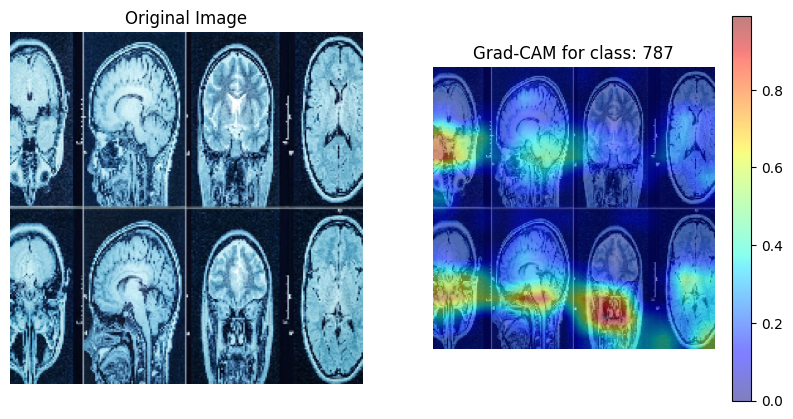

In [6]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
import cv2  # Import OpenCV for resizing
from tensorflow.keras import backend as K

# Load a pre-trained VGG16 model
model = VGG16(weights='imagenet')

# Load an image to test
img_path = 'ct scan.jpg'  # Replace with your image path
img = image.load_img(img_path, target_size=(224, 224))  # Resize to 224x224
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array = tf.keras.applications.vgg16.preprocess_input(img_array)

# Define a function to compute Grad-CAM
def compute_grad_cam(model, img_array, class_idx=None):
    # Get the last convolutional layer's output
    last_conv_layer = model.get_layer('block5_conv3')
    
    # Define a model that outputs the activations of the last conv layer and the predicted class
    grad_model = tf.keras.models.Model([model.input], [last_conv_layer.output, model.output])

    # Compute the gradient of the class output with respect to the last conv layer's output
    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        class_idx = np.argmax(predictions[0]) if class_idx is None else class_idx
        class_output = predictions[:, class_idx]

    # Get the gradient of the output with respect to the convolutional feature map
    grads = tape.gradient(class_output, conv_output)
    
    # Pool the gradients to get the importance of each feature map
    pooled_grads = K.mean(grads, axis=(0, 1, 2)).numpy()
    conv_output = conv_output[0].numpy()

    # Weight the feature maps by the importance of each feature
    for i in range(conv_output.shape[-1]):
        conv_output[..., i] *= pooled_grads[i]
    
    # Compute the Grad-CAM heatmap
    heatmap = np.mean(conv_output, axis=-1)  # Average the feature maps
    heatmap = np.maximum(heatmap, 0)  # Remove negative values
    heatmap = heatmap / np.max(heatmap)  # Normalize to [0, 1]
    return heatmap

# Choose the class with the highest probability (if not given)
predictions = model.predict(img_array)
class_idx = np.argmax(predictions[0])

# Compute and visualize Grad-CAM
grad_cam_map = compute_grad_cam(model, img_array, class_idx)

# Resize the heatmap to match the image size
heatmap = cv2.resize(grad_cam_map, (img.size[0], img.size[1]))

# Create two subplots: one for the original image, one for the Grad-CAM overlay
plt.figure(figsize=(10, 5))

# Plot the original image
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')  # Turn off axis

# Plot the Grad-CAM heatmap overlay
plt.subplot(1, 2, 2)
plt.imshow(img)
plt.imshow(heatmap, cmap='jet', alpha=0.5)  # Overlay the heatmap with transparency
plt.colorbar()
plt.title(f"Grad-CAM for class: {class_idx}")
plt.axis('off')  # Turn off axis

# Display the images
plt.show()


1/1 [==============================] - 1s 1s/step


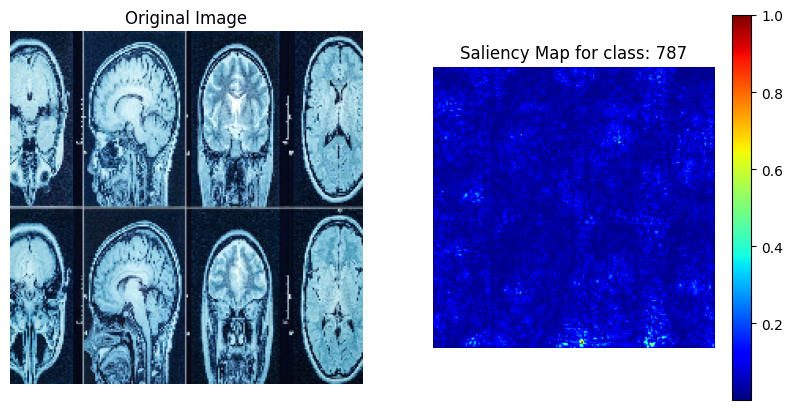

In [8]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image

# Load a pre-trained VGG16 model
model = VGG16(weights='imagenet')

# Load an image to test
img_path = 'ct scan.jpg'  # Replace with your image path
img = image.load_img(img_path, target_size=(224, 224))  # Resize to 224x224
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array = tf.keras.applications.vgg16.preprocess_input(img_array)

# Convert img_array to a Tensor
img_tensor = tf.convert_to_tensor(img_array)

# Define a function to compute the saliency map
def compute_saliency_map(model, img_tensor, class_idx=None):
    # Ensure that the model's output is a class prediction
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)  # Watch the input image for gradients
        predictions = model(img_tensor)
        class_idx = np.argmax(predictions[0]) if class_idx is None else class_idx
        class_output = predictions[:, class_idx]

    # Get the gradients of the output class with respect to the input image
    grads = tape.gradient(class_output, img_tensor)
    
    # Compute the absolute value of the gradients (magnitude of influence)
    saliency_map = tf.reduce_max(tf.abs(grads), axis=-1)[0].numpy()  # Get the max across channels
    return saliency_map

# Choose the class with the highest probability (if not given)
predictions = model.predict(img_array)
class_idx = np.argmax(predictions[0])

# Compute the saliency map
saliency_map = compute_saliency_map(model, img_tensor, class_idx)

# Normalize the saliency map to [0, 1]
saliency_map = np.maximum(saliency_map, 0)  # Remove negative values
saliency_map = saliency_map / np.max(saliency_map)  # Normalize to [0, 1]

# Display the original image and saliency map side by side
plt.figure(figsize=(10, 5))

# Plot the original image
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')  # Turn off axis

# Plot the saliency map
plt.subplot(1, 2, 2)
plt.imshow(saliency_map, cmap='jet')  # Use 'jet' color map
plt.colorbar()
plt.title(f"Saliency Map for class: {class_idx}")
plt.axis('off')  # Turn off axis

plt.show()
